Task 1 - Data Analysis and Preprocessing

In [1]:
# --- Module 1: Imports ---
import sys
import os
import pandas as pd
import numpy as np

# Add project root for src module
PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

# Import task1_data_analysis module
import src.task1_data_analysis as tda

1.1: Data Cleaning

In [2]:
# --- Module 2: Data Cleaning ---

# Load data
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Clean data
fraud_df, ip_df = tda.clean_fraud_data(fraud_df, ip_df)

# --- 2. Handle Missing Values (Extra Check) ---
numeric_cols = fraud_df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols:
    if fraud_df[col].isnull().sum() > 0:
        median_value = fraud_df[col].median()
        fraud_df[col].fillna(median_value, inplace=True)
        print(f"Filled missing numeric values in {col} with median: {median_value}")

categorical_cols = fraud_df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    if fraud_df[col].isnull().sum() > 0:
        mode_value = fraud_df[col].mode()[0]
        fraud_df[col].fillna(mode_value, inplace=True)
        print(f"Filled missing categorical values in {col} with mode: {mode_value}")

# IP-Country extra check
ip_df.dropna(subset=['lower_bound_ip_address', 'upper_bound_ip_address', 'country'], inplace=True)

# --- Verification ---
print("\n--- Final Shapes ---")
print("Fraud Data:", fraud_df.shape)
print("IP-Country Data:", ip_df.shape)

print("\n--- Fraud Data Types ---")
print(fraud_df.dtypes)
print("\n--- IP-Country Data Types ---")
print(ip_df.dtypes)

print("\n--- Fraud Data Cleaning Completed ---")



--- Final Shapes ---
Fraud Data: (151112, 11)
IP-Country Data: (138846, 3)

--- Fraud Data Types ---
user_id                    int64
signup_time       datetime64[ns]
purchase_time     datetime64[ns]
purchase_value             int64
device_id                 object
source                  category
browser                 category
sex                     category
age                        int64
ip_address                 int64
class                      int64
dtype: object

--- IP-Country Data Types ---
lower_bound_ip_address       int64
upper_bound_ip_address       int64
country                   category
dtype: object

--- Fraud Data Cleaning Completed ---


1.2. Exploratory Data Analysis

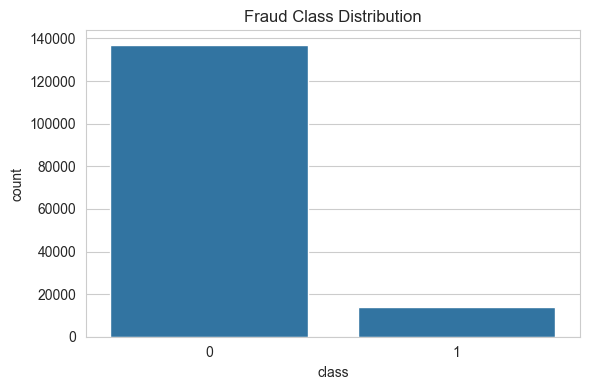

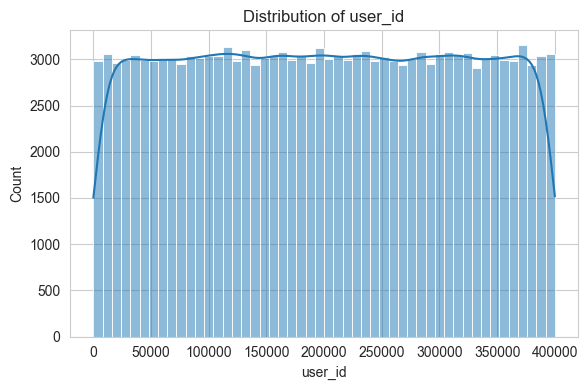

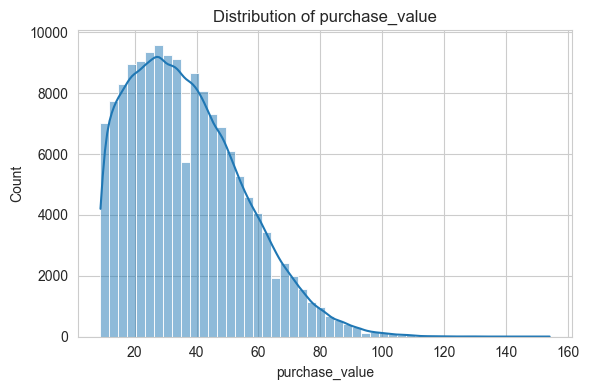

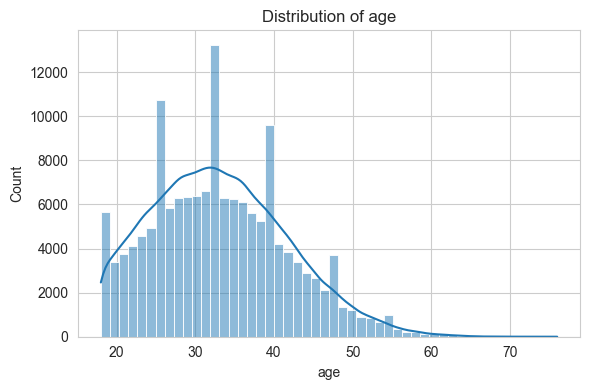

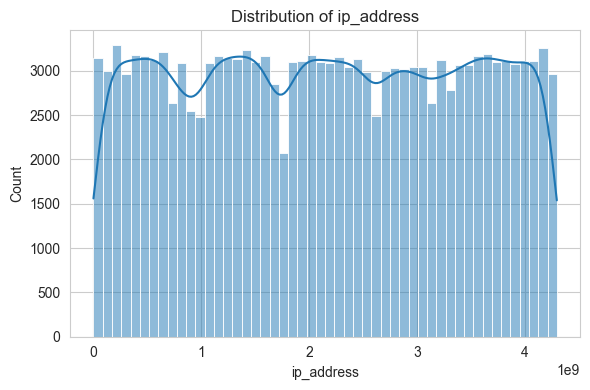

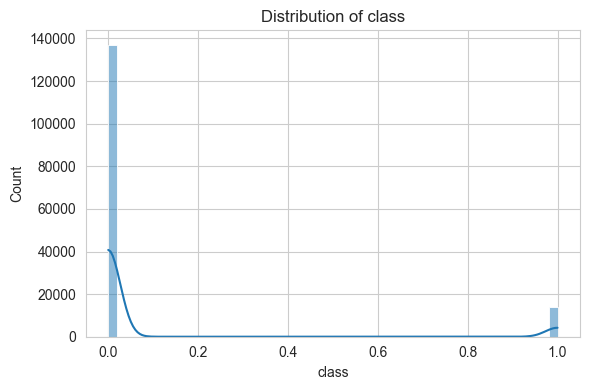

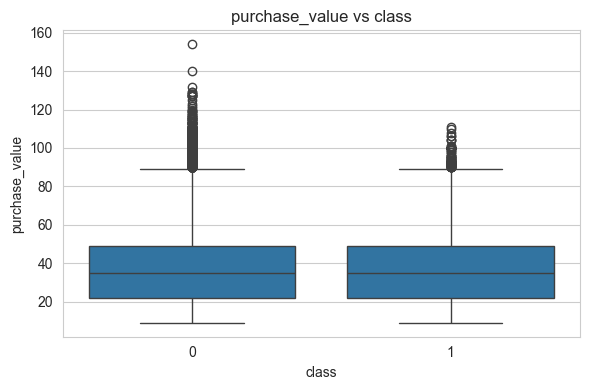

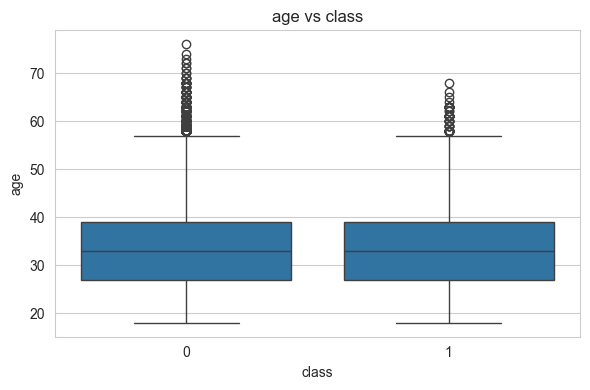

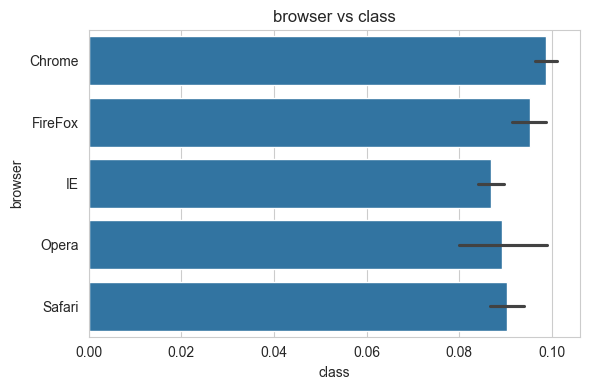

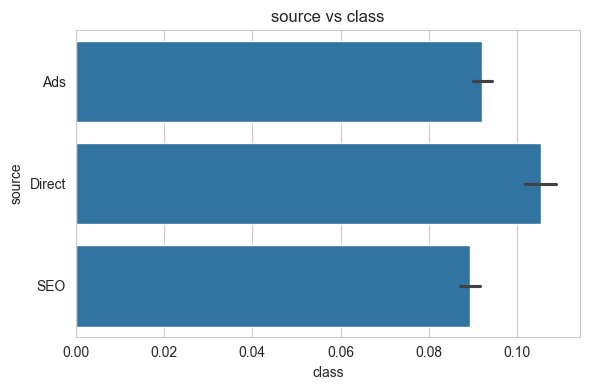

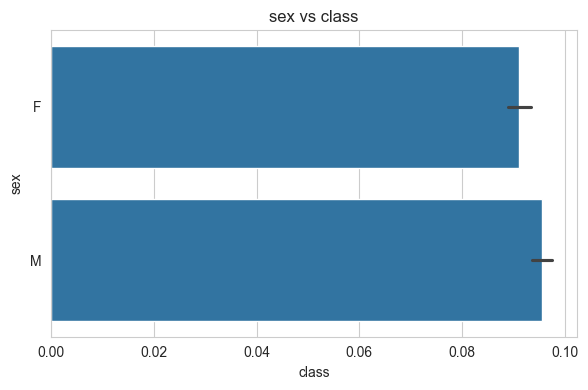

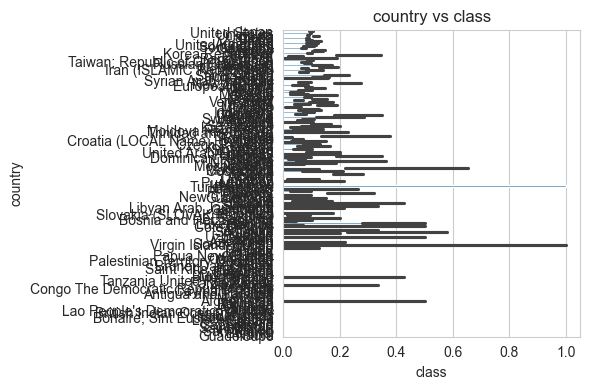

Fraud rate by country:
 country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
                           ...   
Uganda                   0.000000
Vanuatu                  0.000000
Yemen                    0.000000
Zambia                   0.000000
Zimbabwe                 0.000000
Name: class, Length: 182, dtype: float64


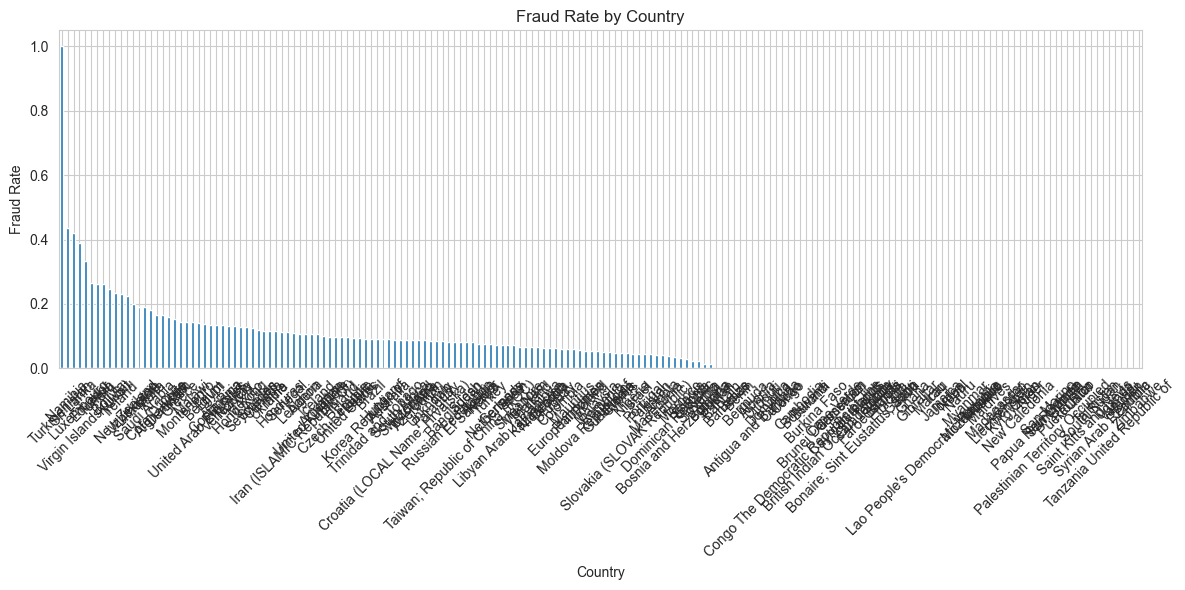

In [8]:
# --- Module 3: EDA for Fraud Dataset ---
# --------------------------------------------

# 1. Class Distribution Analysis
tda.plot_class_distribution(
    fraud_df,
    target_col='class',
    title='Fraud Class Distribution'
)

# 2. Univariate Analysis: numeric features
numeric_cols = fraud_df.select_dtypes(include='number').columns.tolist()
tda.univariate_analysis(fraud_df, numeric_cols)

# 3. Bivariate Analysis: selected numeric features vs target
bivariate_features = ['purchase_value', 'age', 'hour_of_day', 'time_since_signup']
for feature in bivariate_features:
    if feature in fraud_df.columns:
        tda.bivariate_analysis(fraud_df, feature=feature, target='class', kind='box')

# 4. Bivariate Analysis: categorical features vs target
categorical_features = ['browser', 'source', 'sex', 'country']
for feature in categorical_features:
    if feature in fraud_df.columns:
        tda.bivariate_analysis(fraud_df, feature=feature, target='class', kind='bar')

# 5. Fraud rate by country
fraud_country = tda.fraud_by_country(fraud_df)
print("Fraud rate by country:\n", fraud_country)

# Optional: visualize fraud rate by country
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
fraud_country.plot(kind='bar')
plt.title("Fraud Rate by Country")
plt.ylabel("Fraud Rate")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1.3. Geolocation Integration

Step 1: Convert IP addresses to integer format

In [9]:
# --- Step 1: Convert IP addresses to integer format ---

# Fraud dataset
if fraud_df['ip_address'].dtype != 'int64':
    fraud_df['ip_address'] = fraud_df['ip_address'].astype(int)
    print("Converted fraud_df['ip_address'] to integer.")
else:
    print("fraud_df['ip_address'] is already integer.")

# IP-Country dataset
for col in ['lower_bound_ip_address', 'upper_bound_ip_address']:
    if ip_df[col].dtype != 'int64':
        ip_df[col] = ip_df[col].astype(int)
        print(f"Converted ip_df['{col}'] to integer.")
    else:
        print(f"ip_df['{col}'] is already integer.")

# Verify the conversion
print("\n--- Data Types After Conversion ---")
print(fraud_df.dtypes[['ip_address']])
print(ip_df.dtypes[['lower_bound_ip_address','upper_bound_ip_address']])

fraud_df['ip_address'] is already integer.
ip_df['lower_bound_ip_address'] is already integer.
ip_df['upper_bound_ip_address'] is already integer.

--- Data Types After Conversion ---
ip_address    int64
dtype: object
lower_bound_ip_address    int64
upper_bound_ip_address    int64
dtype: object


Step 2: Merge Fraud_Data with IP-Country mapping 

In [10]:
# --- Step 2: Merge Fraud_Data with IP-Country mapping ---

# Ensure ip_df has all necessary columns
print(ip_df.columns)
# Should include: ['lower_bound_ip_address', 'upper_bound_ip_address', 'country']

# Sort data
fraud_df_sorted = fraud_df.sort_values('ip_address')
ip_df_sorted = ip_df.sort_values('lower_bound_ip_address')

# Merge using merge_asof
fraud_df_merged = pd.merge_asof(
    fraud_df_sorted,
    ip_df_sorted,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward',
    suffixes=('', '_ip')  # to avoid duplicate column names
)

# Check the columns after merge
print(fraud_df_merged.columns)

# Filter rows where ip_address <= upper_bound_ip_address
if 'upper_bound_ip_address' in fraud_df_merged.columns:
    fraud_df_merged = fraud_df_merged[
        fraud_df_merged['ip_address'] <= fraud_df_merged['upper_bound_ip_address']
    ]
elif 'upper_bound_ip_address_ip' in fraud_df_merged.columns:  # check for suffix
    fraud_df_merged = fraud_df_merged[
        fraud_df_merged['ip_address'] <= fraud_df_merged['upper_bound_ip_address_ip']
    ]
else:
    raise KeyError("upper_bound_ip_address column not found after merge!")

# Drop IP range columns if desired
drop_cols = [c for c in ['lower_bound_ip_address', 'upper_bound_ip_address', 
                          'lower_bound_ip_address_ip', 'upper_bound_ip_address_ip'] 
             if c in fraud_df_merged.columns]
fraud_df_merged.drop(columns=drop_cols, inplace=True)

# Preview
print(fraud_df_merged[['ip_address', 'country']].head())


Index(['lower_bound_ip_address', 'upper_bound_ip_address', 'country'], dtype='object')
Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'country', 'lower_bound_ip_address', 'upper_bound_ip_address',
       'country_ip'],
      dtype='object')
     ip_address    country
634    16778864  Australia
635    16842045   Thailand
636    16843656      China
637    16938732      China
638    16971984   Thailand


In [5]:
# After merge_asof
fraud_df_sorted = fraud_df.sort_values('ip_address')
ip_df_sorted = ip_df.sort_values('lower_bound_ip_address')

fraud_df_merged = pd.merge_asof(
    fraud_df_sorted,
    ip_df_sorted,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward',
    suffixes=('', '_ip')  # just to handle duplicate names
)

# Keep only rows where ip_address <= upper_bound_ip_address
fraud_df_merged = fraud_df_merged[
    fraud_df_merged['ip_address'] <= fraud_df_merged['upper_bound_ip_address']
]

# Drop unnecessary columns
columns_to_drop = [
    'lower_bound_ip_address', 'upper_bound_ip_address',
    'lower_bound_ip_address_ip', 'upper_bound_ip_address_ip',
    'country_ip'
]
fraud_df_merged.drop(columns=[c for c in columns_to_drop if c in fraud_df_merged.columns], inplace=True)

# Verify final columns
print(fraud_df_merged.columns)
print(fraud_df_merged[['ip_address', 'country']].head())

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'country'],
      dtype='object')
     ip_address    country
634    16778864  Australia
635    16842045   Thailand
636    16843656      China
637    16938732      China
638    16971984   Thailand


Step 3: -	Analyze fraud patterns by country

D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\src\task1_data_analysis.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


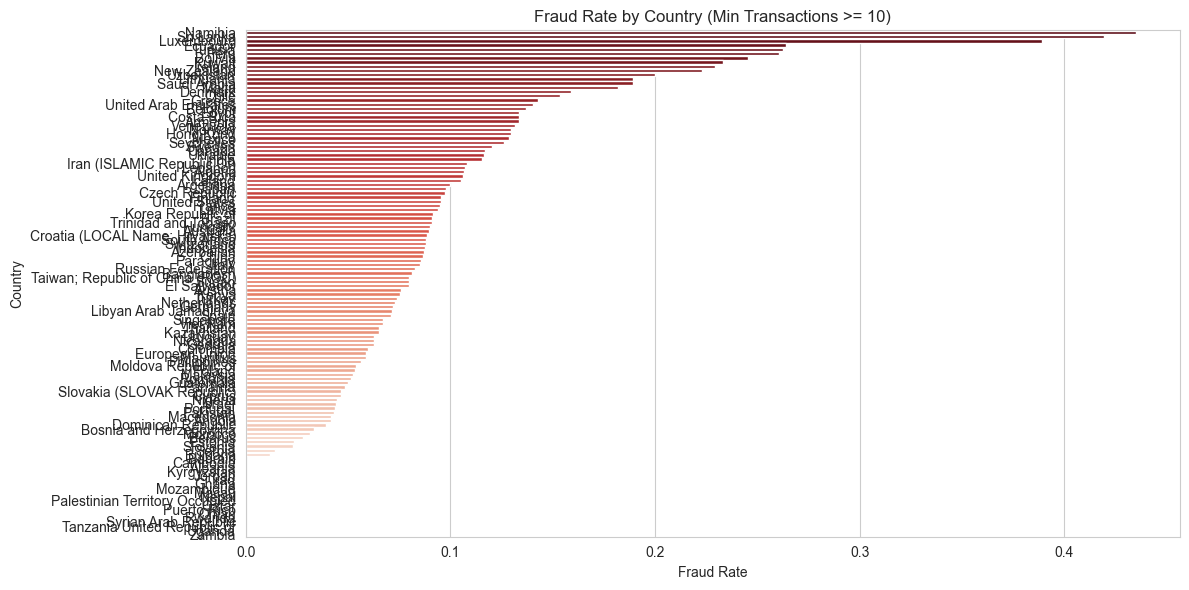

,country,total_transactions,fraud_count,fraud_rate
115,Namibia,23,10,0.434783
154,Sri Lanka,31,13,0.419355
98,Luxembourg,72,28,0.388889
51,Ecuador,106,28,0.264151
164,Tunisia,118,31,0.262712
131,Peru,119,31,0.260504
20,Bolivia,53,13,0.245283
89,Kuwait,90,21,0.233333
80,Ireland,240,55,0.229167
120,New Zealand,278,62,0.223022


In [6]:
import importlib
import src.task1_data_analysis as tda
importlib.reload(tda)  # Reload after updating the .py file

# Run fraud by country analysis
country_stats = tda.fraud_by_country_analysis(fraud_df_merged, min_transactions=10, plot=True)

# View top 10
country_stats.head(10)